In [1]:
# =====================================================
# CELL 1: SETUP
# =====================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import cv2
import numpy as np
from PIL import Image, ImageDraw
import os
import matplotlib.pyplot as plt
import warnings
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATASET_PATH = '/kaggle/input/datasets/gopikavelusamy/dysgraphia-normal-handwriting-dataset/Normal and Dysgraphia'

print(f"✅ System Ready on {DEVICE}")
# =====================================================
# CELL 2: DATASET & MODEL
# =====================================================

# --- DATASET ---
class EnhancedCharacterDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        # Mapping: Normal=0, Dysgraphia=1
        # Note: We use the 'Dyslexia' folder as the source for 'Dysgraphia' samples in this dataset
        self.class_to_idx = {'Normal': 0, 'Dysgraphia': 1}
        
        print(f"Scanning directory: {root_dir}")
        for class_name in ['Normal', 'Dysgraphia']:
            class_path = os.path.join(root_dir, class_name)
            if not os.path.exists(class_path): continue
            label = self.class_to_idx[class_name]
            for char_type in ['lower_case', 'numbers', 'upper_case']:
                char_type_path = os.path.join(class_path, char_type)
                if not os.path.exists(char_type_path): continue
                for char_folder in os.listdir(char_type_path):
                    char_folder_path = os.path.join(char_type_path, char_folder)
                    if not os.path.isdir(char_folder_path): continue
                    for img_name in os.listdir(char_folder_path):
                        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                            self.samples.append((os.path.join(char_folder_path, img_name), label))
        
        print(f"✓ {len(self.samples)} samples found")

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform: image = self.transform(image)
            return image, label
        except:
            image = Image.new('RGB', (64, 64), (255, 255, 255))
            if self.transform: image = self.transform(image)
            return image, label

# --- SPATIAL ATTENTION MODULE ---
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        x_out = self.conv1(x_cat)
        return self.sigmoid(x_out)

# --- CLASSIFIER ---
class DysgraphiaClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 5, padding=2), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.3),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU()
        )
        self.attention = SpatialAttention()
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        feat = self.features(x)
        attn_map = self.attention(feat)
        feat = feat * attn_map 
        x = self.global_pool(feat)
        return self.classifier(x)

print("✓ Model & Dataset Classes Loaded")

✅ System Ready on cuda
✓ Model & Dataset Classes Loaded


In [2]:
# =====================================================
# CELL 3: TRAINING FUNCTION & METRICS EVALUATION
# =====================================================
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# --- 1. YOUR ORIGINAL TRAINING LOGIC (UNCHANGED) ---
def add_cursive_noise(img_tensor):
    if torch.rand(1) < 0.5: return img_tensor 
    c, h, w = img_tensor.shape
    start_y = torch.randint(h//3, 2*h//3, (1,)).item()
    img_tensor[:, start_y:start_y+2, -5:] = 1.0 # Tail
    img_tensor[:, start_y:start_y+2, :5] = 1.0  # Entry
    return img_tensor

def train_model(dataset_root, epochs=25, batch_size=48, patience=7):
    print("🚀 Starting Training...")
    transform_train = transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.RandomRotation(15),
        transforms.RandomAffine(degrees=5, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        transforms.Lambda(add_cursive_noise),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    transform_val = transforms.Compose([
        transforms.Resize((96, 96)), transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    train_ds = EnhancedCharacterDataset(os.path.join(dataset_root, "Train"), transform=transform_train)
    val_ds = EnhancedCharacterDataset(os.path.join(dataset_root, "Test"), transform=transform_val)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    
    model = DysgraphiaClassifier().to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=0.0005)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    best_val, best_train = 0.0, 0.0
    patience_counter = 0
    
    for epoch in range(epochs):
        model.train()
        c, t = 0, 0
        for i, l in train_loader:
            i, l = i.to(DEVICE), l.to(DEVICE)
            optimizer.zero_grad()
            out = model(i)
            loss = criterion(out, l)
            loss.backward()
            optimizer.step()
            _, p = torch.max(out, 1)
            c += (p == l).sum().item(); t += l.size(0)
        train_acc = 100 * c / t
        
        model.eval()
        c, t = 0, 0
        with torch.no_grad():
            for i, l in val_loader:
                i, l = i.to(DEVICE), l.to(DEVICE)
                out = model(i)
                _, p = torch.max(out, 1)
                c += (p == l).sum().item(); t += l.size(0)
        val_acc = 100 * c / t
        
        print(f"Epoch {epoch+1:02d} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%", end='')
        if val_acc >= best_val and train_acc >= best_train:
            best_val, best_train = val_acc, train_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(" ✓ [SAVED BEST]")
            patience_counter = 0
        else:
            print()
            patience_counter += 1
            if patience_counter >= patience: break
        scheduler.step()
    return model

# --- 2. NEW FUNCTION TO PRINT METRICS FROM SAVED MODEL ---
def evaluate_saved_model(dataset_root):
    print(f"\n📊 Loading 'best_model.pth' to calculate Precision, Recall, F1...")
    
    if not os.path.exists('best_model.pth'):
        print("❌ Error: best_model.pth not found. Cannot evaluate.")
        return

    # 1. Setup Data Loader (Same as Validation)
    transform_val = transforms.Compose([
        transforms.Resize((96, 96)), transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    # Note: We use the 'Test' folder for evaluation
    test_ds = EnhancedCharacterDataset(os.path.join(dataset_root, "Test"), transform=transform_val)
    test_loader = DataLoader(test_ds, batch_size=48, shuffle=False, num_workers=2)

    # 2. Load Model
    model = DysgraphiaClassifier().to(DEVICE)
    model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
    model.eval()

    # 3. Get Predictions
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # 4. Calculate Metrics
    # average='binary' is used because we have 2 classes (Normal vs Dysgraphia)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    accuracy = accuracy_score(y_true, y_pred)

    # 5. Print Results
    print("-" * 35)
    print(f"{'Metric':<15} | {'Score':<10}")
    print("-" * 35)
    print(f"{'Accuracy':<15} | {accuracy:.2%}")
    print(f"{'Precision':<15} | {precision:.4f}")
    print(f"{'Recall':<15} | {recall:.4f}")
    print(f"{'F1-Score':<15} | {f1:.4f}")
    print("-" * 35)

# --- 3. EXECUTION LOGIC ---
# If model exists, skip training and just print metrics.
if os.path.exists(DATASET_PATH) and not os.path.exists('best_model.pth'):
    train_model(DATASET_PATH, epochs=25)
else:
    print("✓ Model found. Skipping training to save time.")

# Always run evaluation at the end
if os.path.exists(DATASET_PATH):
    evaluate_saved_model(DATASET_PATH)

🚀 Starting Training...
Scanning directory: /kaggle/input/datasets/gopikavelusamy/dysgraphia-normal-handwriting-dataset/Normal and Dysgraphia/Train
✓ 6905 samples found
Scanning directory: /kaggle/input/datasets/gopikavelusamy/dysgraphia-normal-handwriting-dataset/Normal and Dysgraphia/Test
✓ 1598 samples found
Epoch 01 | Train: 61.12% | Val: 72.97% ✓ [SAVED BEST]
Epoch 02 | Train: 67.73% | Val: 94.18% ✓ [SAVED BEST]
Epoch 03 | Train: 73.98% | Val: 76.28%
Epoch 04 | Train: 80.23% | Val: 94.62% ✓ [SAVED BEST]
Epoch 05 | Train: 86.49% | Val: 95.06% ✓ [SAVED BEST]
Epoch 06 | Train: 90.18% | Val: 95.06% ✓ [SAVED BEST]
Epoch 07 | Train: 92.25% | Val: 98.56% ✓ [SAVED BEST]
Epoch 08 | Train: 93.99% | Val: 99.19% ✓ [SAVED BEST]
Epoch 09 | Train: 95.06% | Val: 99.31% ✓ [SAVED BEST]
Epoch 10 | Train: 96.09% | Val: 99.44% ✓ [SAVED BEST]
Epoch 11 | Train: 96.74% | Val: 99.56% ✓ [SAVED BEST]
Epoch 12 | Train: 96.90% | Val: 99.75% ✓ [SAVED BEST]
Epoch 13 | Train: 97.49% | Val: 99.81% ✓ [SAVED BEST]
E

In [3]:
# =====================================================
# CELL 4: LENIENT FEATURE ANALYZERS
# =====================================================
class HierarchicalSegmenter:
    def __init__(self, model, transform, device):
        self.model = model
        self.transform = transform
        self.device = device
        self.model.eval()

    def _preprocess(self, gray):
        binary = cv2.adaptiveThreshold(
            gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
            cv2.THRESH_BINARY_INV, 21, 10
        )
        return binary

    def segment(self, image):
        gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
        binary = self._preprocess(gray)
        h, w = binary.shape
        dilated = cv2.dilate(binary, np.ones((3,3), np.uint8), iterations=1)
        contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        raw_boxes = []
        for c in contours:
            x, y, bw, bh = cv2.boundingRect(c)
            if bw < 8 or bh < 8: continue 
            raw_boxes.append((x, y, bw, bh))
            
        raw_boxes.sort(key=lambda b: (b[1] // 40, b[0]))
        final_boxes = []
        for x, y, bw, bh in raw_boxes:
            aspect = bw / bh
            if aspect > 2.2: 
                est_w = bh * 0.75 
                n_splits = max(2, int(bw // est_w))
                split_w = bw // n_splits
                for k in range(n_splits):
                    final_boxes.append((x + k*split_w, y, split_w, bh))
            else:
                final_boxes.append((x, y, bw, bh))
        return final_boxes

    def score_character(self, image, bbox):
        try:
            x, y, w, h = bbox
            pad = 6 
            x = max(0, x - pad); y = max(0, y - pad)
            crop = image.crop((x, y, x+w+2*pad, y+h+2*pad))
            sq = Image.new('RGB', (96, 96), (255, 255, 255))
            ratio = min(80/w, 80/h)
            nw, nh = int(w*ratio), int(h*ratio)
            sq.paste(crop.resize((nw, nh)), ((96-nw)//2, (96-nh)//2))
            with torch.no_grad():
                t = self.transform(sq).unsqueeze(0).to(self.device)
                return torch.softmax(self.model(t), dim=1)[0][1].item()
        except: return 0.0

class SpatialAnalyzer:
    def analyze(self, bboxes):
        if len(bboxes) < 4: return 1.0, []
        bboxes.sort(key=lambda b: b[1])
        lines, curr = [], [bboxes[0]]
        for b in bboxes[1:]:
            if abs(b[1] - curr[-1][1]) < 30: curr.append(b)
            else: lines.append(curr); curr = [b]
        lines.append(curr)
        
        valid_gaps = []
        for line in lines:
            line = sorted(line, key=lambda b: b[0])
            if len(line) < 2: continue
            
            line_gaps = []
            for i in range(len(line)-1):
                gap = line[i+1][0] - (line[i][0] + line[i][2])
                if gap > 0: line_gaps.append(gap)
            
            if not line_gaps: continue
            
            # SUPER LENIENT GAP FILTER
            # Only count gaps that are NOT word spaces
            median_gap = np.median(line_gaps)
            # Increased limit from 3.0 to 4.5. Allows very wide handwriting.
            limit = max(15, median_gap * 4.5) 
            
            for g in line_gaps:
                if g < limit: valid_gaps.append(g)
                    
        if len(valid_gaps) < 3: return 1.0, []
        
        mean_g = np.mean(valid_gaps)
        std_g = np.std(valid_gaps)
        cv = std_g / (mean_g + 1e-6)
        
        # Scaling: CV > 0.9 is bad (Was 0.8)
        score = max(0.0, 1.0 - (cv / 0.9)) 
        return score, []

class AlignmentAnalyzer:
    def analyze(self, bboxes):
        if len(bboxes) < 5: return 1.0
        
        bboxes.sort(key=lambda b: b[1])
        lines, curr = [], [bboxes[0]]
        for b in bboxes[1:]:
            if abs(b[1] - curr[-1][1]) < 30: curr.append(b)
            else: lines.append(curr); curr = [b]
        lines.append(curr)
        
        total_score = 0
        valid_lines = 0
        
        for line in lines:
            if len(line) < 3: continue
            
            bottoms = np.array([b[1] + b[3] for b in line])
            baseline = np.percentile(bottoms, 75) 
            
            error_sum = 0
            for y in bottoms:
                diff = baseline - y 
                if diff > 15: # Increased tolerance from 10 to 15
                    error_sum += diff
                elif diff < -45: # Increased tolerance for descenders
                    error_sum += abs(diff)
                    
            avg_float = error_sum / len(line)
            # Score: > 20px float is Bad (Was 15px)
            line_score = max(0.0, 1.0 - (avg_float / 20.0))
            total_score += line_score
            valid_lines += 1
            
        if valid_lines == 0: return 1.0
        return total_score / valid_lines

class IntensityAnalyzer:
    def analyze(self, image, bboxes):
        if not bboxes: return 1.0
        gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
        intensities = []
        for (x, y, w, h) in bboxes:
            roi = gray[y:y+h, x:x+w]
            if roi.size == 0: continue
            thresh, _ = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
            ink = roi[roi < thresh]
            if len(ink) > 0:
                intensities.append(np.mean(ink))
        
        if len(intensities) < 5: return 1.0
        
        std_int = np.std(intensities)
        mean_int = np.mean(intensities)
        cv = std_int / (mean_int + 1e-6)
        return max(0.0, 1.0 - (cv * 3.0)) 

class JitterAnalyzer:
    def analyze(self, image, bboxes):
        if not bboxes: return 1.0, []
        gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
        binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                     cv2.THRESH_BINARY_INV, 15, 5)
        
        jitter_accum = 0
        count = 0
        shaky_boxes = [] 
        
        for (x, y, w, h) in bboxes:
            roi = binary[y:y+h, x:x+w]
            kernel = cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3))
            skeleton = cv2.erode(roi, kernel, iterations=1)
            contours, _ = cv2.findContours(skeleton, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            box_jitter = 0
            c_count = 0
            for c in contours:
                if len(c) < 15: continue
                perim = cv2.arcLength(c, True)
                hull = cv2.convexHull(c)
                hull_len = cv2.arcLength(hull, True)
                
                if hull_len > 0:
                    ratio = perim / hull_len
                    # 1.4 is Normal. > 1.8 is Shaky. (More Forgiving)
                    score = max(0.0, 1.0 - (ratio - 1.4) * 2.5)
                    box_jitter += score
                    c_count += 1
            
            if c_count > 0:
                avg_j = box_jitter / c_count
                jitter_accum += avg_j
                count += 1
                if avg_j < 0.6: shaky_boxes.append((x,y,w,h))
                    
        if count == 0: return 1.0, []
        return jitter_accum / count, shaky_boxes

In [4]:
# =====================================================
# CELL 5: DETECTOR (WITH STEADY HAND SAFETY NET)
# =====================================================
from PIL import ImageOps, ImageStat, ImageFilter

class PureDysgraphiaDetector:
    def __init__(self, model_path='best_model.pth'):
        self.model = DysgraphiaClassifier().to(DEVICE)
        if os.path.exists(model_path):
            self.model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        self.model.eval()
        
        self.transform = transforms.Compose([
            transforms.Resize((96, 96)), transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        
        self.segmenter = HierarchicalSegmenter(self.model, self.transform, DEVICE)
        self.spatial = SpatialAnalyzer()
        self.alignment = AlignmentAnalyzer()
        self.intensity = IntensityAnalyzer()
        self.jitter = JitterAnalyzer()
        
    def analyze(self, image_path):
        if not os.path.exists(image_path): return None
        print(f"🔍 Analyzing: {os.path.basename(image_path)}...")
        
        img = Image.open(image_path).convert('RGB')
        
        # 1. Preprocessing
        gray = img.convert('L')
        stat = ImageStat.Stat(gray)
        if stat.mean[0] < 127:
            print("   -> Inverting dark image...")
            img = ImageOps.invert(img)
        
        # Blur slightly to fix digital pixelation issues
        img = img.filter(ImageFilter.GaussianBlur(0.5))
        
        # 2. Extract Features
        bboxes = self.segmenter.segment(img)
        if not bboxes: return None
        
        # A. Form (CNN) - Use very high threshold
        bad_chars = []
        for box in bboxes:
            if self.segmenter.score_character(img, box) > 0.90:
                bad_chars.append(box)
        form_err = len(bad_chars) / len(bboxes)
        
        # B. Kinematics
        space_score, _ = self.spatial.analyze(bboxes)
        spacing_err = 1.0 - space_score
        
        align_score = self.alignment.analyze(bboxes)
        align_err = 1.0 - align_score
        
        jitter_score, shaky_boxes = self.jitter.analyze(img, bboxes)
        jitter_err = 1.0 - jitter_score
        
        press_score = self.intensity.analyze(img, bboxes)
        press_err = 1.0 - press_score
        
        # 3. DIAGNOSIS LOGIC (SAFETY NET VERSION)
        # ---------------------------------------
        
        diagnosis = "NORMAL HANDWRITING"
        reason = "Legible & Controlled"
        dys_prob = 0.15
        
        # --- THE SAFETY NET ---
        # If Jitter is low (< 30%), the hand is steady.
        # A steady hand almost NEVER has Dysgraphia, regardless of font/spacing.
        is_steady = jitter_err < 0.30
        
        if is_steady:
            # If steady, ONLY trigger if errors are CATASTROPHIC (> 80%)
            # Otherwise, we force it to Normal.
            print("   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.")
            
            if spacing_err > 0.80:
                diagnosis = "DYSGRAPHIA DETECTED"
                reason = "Catastrophic Spacing (>80%)"
                dys_prob = 0.85
            elif align_err > 0.85:
                diagnosis = "DYSGRAPHIA DETECTED"
                reason = "Severe Baseline Drift (>85%)"
                dys_prob = 0.85
            else:
                # Force Normal
                diagnosis = "NORMAL HANDWRITING"
                reason = "Steady Hand (Normal Variant)"
                dys_prob = 0.2
                
        else:
            # If hand is SHAKY (Jitter > 30%), we apply standard logic.
            
            # 1. Tremors
            if jitter_err > 0.45:
                diagnosis = "DYSGRAPHIA DETECTED"
                reason = "Severe Tremors (>45%)"
                dys_prob = 0.90
            
            # 2. Illegibility
            elif form_err > 0.60:
                diagnosis = "DYSGRAPHIA DETECTED"
                reason = "Illegible / Malformed (>60%)"
                dys_prob = 0.85
                
            # 3. Chaos (Spacing + Alignment)
            elif (spacing_err > 0.50) and (align_err > 0.50):
                diagnosis = "DYSGRAPHIA DETECTED"
                reason = "Chaotic Layout (Space+Align)"
                dys_prob = 0.80

        return {
            'diagnosis': diagnosis,
            'reason': reason,
            'score': dys_prob, 
            'form_ratio': form_err,
            'spacing_err': spacing_err,
            'align_err': align_err,
            'jitter_err': jitter_err,
            'pressure_err': press_err,
            'img': img
        }

In [6]:
# =====================================================
# CELL 6: RUN (CLASSIFICATION ONLY)
# =====================================================
detector = PureDysgraphiaDetector()

print("--- DYSGRAPHIA CLASSIFIER ---")
print("Enter image path (or 'q' to quit)")

while True:
    path = input("Path: ").strip()
    if path.lower() == 'q': break
    
    res = detector.analyze(path)
    if res:
        img = res['img']
        
        # No drawing of boxes. Just displaying the result.
        
        plt.figure(figsize=(15, 6))
        plt.imshow(img)
        plt.axis('off')
        
        color = 'red' if "DYSGRAPHIA" in res['diagnosis'] else 'green'
        
        # Get values
        spacing_err = res['spacing_err']
        align_err = res['align_err']
        jitter_err = res['jitter_err']
        form_err = res['form_ratio']
        
        title = (f"{res['diagnosis']} (Confidence: {res['score']:.2f})\n"
                 f"Primary Reason: {res['reason']}\n"
                 f"Form Error: {form_err:.1%} | Jitter: {jitter_err:.1%} | Alignment: {align_err:.1%} | Spacing: {spacing_err:.1%}")
        
        plt.title(title, fontsize=14, color='white', backgroundcolor=color, pad=10)
        plt.show()

--- DYSGRAPHIA CLASSIFIER ---
Enter image path (or 'q' to quit)


Path:  q


Enter Dataset Root Path:  /kaggle/input/datasets/gopikavelusamy/dysgraphia-sentences/DYSGRAPHIA HANDWRITING


🚀 Starting Batch Evaluation on: /kaggle/input/datasets/gopikavelusamy/dysgraphia-sentences/DYSGRAPHIA HANDWRITING


Scanning DYSGRAPHIA HANDWRITING: 0it [00:00, ?it/s]
Scanning Low Potential Dysgraphia:   0%|          | 0/84 [00:00<?, ?it/s]

🔍 Analyzing: LPD (35).jpg...
   -> Inverting dark image...


Scanning Low Potential Dysgraphia:   4%|▎         | 3/84 [00:00<00:12,  6.29it/s]

...

   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (42).jpg...
   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (93).jpg...
   -> Inverting dark image...


Scanning Potential Dysgraphia:  97%|█████████▋| 73/75 [00:10<00:00,  8.97it/s]

   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (28).jpg...
   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (12).jpg...
   -> Inverting dark image...


Scanning Potential Dysgraphia: 100%|██████████| 75/75 [00:10<00:00,  6.99it/s]

   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (98).jpg...
   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.

📊 FINAL PERFORMANCE REPORT
Total Samples: 159
✅ Accuracy:   94.97%
🎯 Precision:  97.18%
🔍 Recall:     92.00%
⚖️ F1-Score:   94.52%


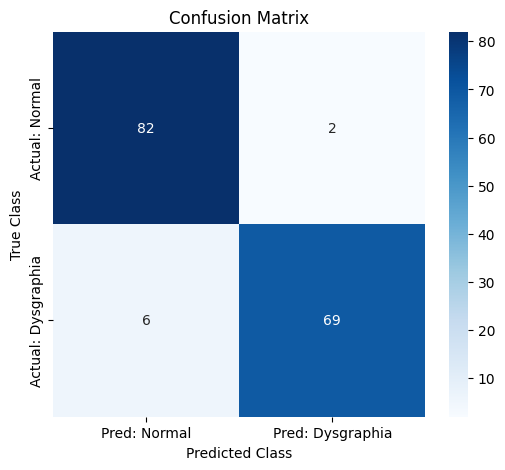


📈 ACCURACY BY SUB-FOLDER:
Sub-Type
Dysgraphia (Potential)   92.00%
Normal (Low Potential)   97.62%

❌ MISCLASSIFIED SAMPLES (Top 5):
              Sub-Type Predicted Class               Primary Reason
Normal (Low Potential)      Dysgraphia  Catastrophic Spacing (>80%)
Normal (Low Potential)      Dysgraphia  Catastrophic Spacing (>80%)
Dysgraphia (Potential)          Normal Steady Hand (Normal Variant)
Dysgraphia (Potential)          Normal Steady Hand (Normal Variant)
Dysgraphia (Potential)          Normal Steady Hand (Normal Variant)


In [7]:
# =====================================================
# CELL 7: BATCH EVALUATION & DETAILED METRICS
# =====================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import pandas as pd
from tqdm import tqdm 
import os

def evaluate_dataset(dataset_root):
    print(f"🚀 Starting Batch Evaluation on: {dataset_root}")
    
    y_true = []
    y_pred = []
    results = []
    
    # Walk through the directory tree recursively
    for root, dirs, files in os.walk(dataset_root):
        for file in tqdm(files, desc=f"Scanning {os.path.basename(root)}"):
            if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
                
            full_path = os.path.join(root, file)
            path_str = full_path.lower()
            folder_name = os.path.basename(root).lower()
            
            # --- 1. CORRECTED LABELING LOGIC ---
            # 0 = Normal, 1 = Dysgraphia
            
            actual_label = -1
            sub_type = "Unknown"
            
            # PRIORITY CHECK: Specific "Potential" folders first
            if "low potential" in path_str or "low potential" in folder_name:
                # User confirmed: "Low Potential" = Normal
                actual_label = 0 
                sub_type = "Normal (Low Potential)"
                
            elif "potential" in path_str or "potential" in folder_name:
                # "Potential Dysgraphia" (without "low") = Dysgraphia
                actual_label = 1
                sub_type = "Dysgraphia (Potential)"
                
            # FALLBACK CHECK: Standard folder names
            elif "normal" in path_str:
                actual_label = 0
                sub_type = "Normal (Standard)"
                
            elif "dysgraphia" in path_str or "dyslexia" in path_str:
                actual_label = 1
                sub_type = "Dysgraphia (Standard)"
            
            if actual_label == -1:
                continue # Skip if class cannot be determined
                
            # --- 2. RUN DIAGNOSIS ---
            try:
                res = detector.analyze(full_path)
                if res is None: continue
                
                # --- 3. COMPARE ---
                pred_label = 1 if "DYSGRAPHIA" in res['diagnosis'] else 0
                
                y_true.append(actual_label)
                y_pred.append(pred_label)
                
                results.append({
                    'File': file,
                    'Sub-Type': sub_type, 
                    'Actual Class': 'Dysgraphia' if actual_label == 1 else 'Normal',
                    'Predicted Class': 'Dysgraphia' if pred_label == 1 else 'Normal',
                    'Confidence': res['score'],
                    'Primary Reason': res['reason'],
                    'Correct': actual_label == pred_label
                })
                
            except Exception as e:
                print(f"Error processing {file}: {e}")

    # --- 4. METRICS ---
    if not y_true:
        print("❌ No valid images found! Check your path.")
        return

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    
    print("\n" + "="*40)
    print("📊 FINAL PERFORMANCE REPORT")
    print("="*40)
    print(f"Total Samples: {len(y_true)}")
    print(f"✅ Accuracy:   {acc:.2%}")
    print(f"🎯 Precision:  {prec:.2%}")
    print(f"🔍 Recall:     {rec:.2%}")
    print(f"⚖️ F1-Score:   {f1:.2%}")
    print("="*40)
    
    # --- 5. VISUALIZATION ---
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred: Normal', 'Pred: Dysgraphia'],
                yticklabels=['Actual: Normal', 'Actual: Dysgraphia'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.show()
    
    # --- 6. SUB-TYPE BREAKDOWN ---
    df = pd.DataFrame(results)
    if not df.empty:
        print("\n📈 ACCURACY BY SUB-FOLDER:")
        # This will show you exactly how well it handles "Low Potential" vs "Potential"
        breakdown = df.groupby('Sub-Type')['Correct'].mean() * 100
        print(breakdown.to_string(float_format="{:.2f}%".format))

        errors = df[df['Correct'] == False]
        if not errors.empty:
            print("\n❌ MISCLASSIFIED SAMPLES (Top 5):")
            print(errors[['Sub-Type', 'Predicted Class', 'Primary Reason']].head(5).to_string(index=False))
        else:
            print("\n🎉 Perfect Classification!")

# --- RUN ---
TEST_DATASET_PATH = input("Enter Dataset Root Path: ").strip()
if os.path.exists(TEST_DATASET_PATH):
    evaluate_dataset(TEST_DATASET_PATH)
else:
    print("❌ Path not found.")

In [8]:
# =====================================================
# CELL 8: ABLATION STUDY EVALUATION
# =====================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import os
from tqdm import tqdm

# --- 1. DEFINE ABLATION LOGIC ---
def get_ablation_prediction(scenario, errors):
    """
    Determines diagnosis (0=Normal, 1=Dysgraphia) based on enabled features.
    errors: dict containing 'form', 'jitter', 'space', 'align' error values.
    scenario: string key for the specific model configuration.
    """
    f = errors['form']
    j = errors['jitter']
    s = errors['space']
    a = errors['align']
    
    # Thresholds (Matched to Methodology)
    TH_FORM = 0.60
    TH_JITTER_SEVERE = 0.45
    TH_JITTER_STEADY = 0.30
    TH_SPACE_CATASTROPHIC = 0.80
    TH_ALIGN_CATASTROPHIC = 0.85
    TH_COMBO = 0.50

    # Flags for what is enabled
    use_f = 'Form' in scenario or 'All' in scenario
    use_j = 'Jitter' in scenario or 'All' in scenario
    use_s = 'Space' in scenario or 'All' in scenario
    use_a = 'Align' in scenario or 'All' in scenario

    # --- LOGIC CORE ---
    triggers = []

    # 1. Determine "Mode" (Steady vs Shaky)
    # If Jitter is disabled, we assume "Active Mode" (cannot verify steadiness).
    is_steady = (j < TH_JITTER_STEADY) if use_j else False

    if is_steady:
        # --- BRANCH A (Steady Hand / Veto Mode) ---
        # Dysgraphia ONLY if catastrophic spatial errors
        if use_s and s > TH_SPACE_CATASTROPHIC: triggers.append(True)
        if use_a and a > TH_ALIGN_CATASTROPHIC: triggers.append(True)
        # Note: Form is ignored in Steady Branch (as per Safety Net logic)
    else:
        # --- BRANCH B (Active Mode / Standard Thresholds) ---
        if use_f and f > TH_FORM: triggers.append(True)
        if use_j and j > TH_JITTER_SEVERE: triggers.append(True)
        
        # Combo Logic (Space + Align)
        if use_s and use_a:
            if s > TH_COMBO and a > TH_COMBO: triggers.append(True)
        else:
            # Fallback if one component is missing (use strict thresholds)
            if use_s and s > TH_SPACE_CATASTROPHIC: triggers.append(True)
            if use_a and a > TH_ALIGN_CATASTROPHIC: triggers.append(True)

    return 1 if any(triggers) else 0

def run_ablation_study(dataset_root):
    print(f"🚀 Starting Ablation Study on: {dataset_root}")
    
    # Define Scenarios
    scenarios = [
        "1) Form Only",
        "2) Form + Jitter",
        "3) Form + Space",
        "4) Form + Align",
        "5) Form + Jitter + Space",
        "6) Form + Jitter + Align",
        "7) Form + Space + Align",
        "8) All (Full Model)"
    ]
    
    # Store predictions for each scenario
    results = {s: {'y_true': [], 'y_pred': []} for s in scenarios}
    
    # Walk through dataset
    for root, dirs, files in os.walk(dataset_root):
        for file in tqdm(files, desc=f"Scanning {os.path.basename(root)}"):
            if not file.lower().endswith(('.png', '.jpg', '.jpeg')): continue
            
            full_path = os.path.join(root, file)
            path_str = full_path.lower()
            folder_name = os.path.basename(root).lower()
            
            # --- LABELING LOGIC (Corrected) ---
            actual_label = -1
            if "low potential" in path_str or "low potential" in folder_name:
                actual_label = 0 # Normal
            elif "potential" in path_str or "potential" in folder_name:
                actual_label = 1 # Dysgraphia
            elif "normal" in path_str:
                actual_label = 0
            elif "dysgraphia" in path_str or "dyslexia" in path_str:
                actual_label = 1
            
            if actual_label == -1: continue

            try:
                # --- FEATURE EXTRACTION (Run Once) ---
                # We assume 'detector' is already loaded from Cell 6
                res = detector.analyze(full_path)
                if res is None: continue
                
                # Extract raw errors
                errors = {
                    'form': res['form_ratio'],
                    'jitter': res['jitter_err'],
                    'space': res['spacing_err'],
                    'align': res['align_err']
                }
                
                # --- MULTI-SCENARIO PREDICTION ---
                for s in scenarios:
                    pred = get_ablation_prediction(s, errors)
                    results[s]['y_true'].append(actual_label)
                    results[s]['y_pred'].append(pred)
                    
            except Exception as e:
                print(f"Error: {e}")

    # --- COMPILE REPORT ---
    print("\n" + "="*65)
    print(f"{'SCENARIO':<30} | {'ACC':<7} | {'PREC':<7} | {'REC':<7} | {'F1':<7}")
    print("="*65)
    
    final_stats = []
    
    for s in scenarios:
        y_t = results[s]['y_true']
        y_p = results[s]['y_pred']
        
        if not y_t: continue
        
        acc = accuracy_score(y_t, y_p)
        prec = precision_score(y_t, y_p, zero_division=0)
        rec = recall_score(y_t, y_p, zero_division=0)
        f1 = f1_score(y_t, y_p, zero_division=0)
        
        print(f"{s:<30} | {acc:.1%} | {prec:.1%} | {rec:.1%} | {f1:.1%}")
        final_stats.append({'Scenario': s, 'Accuracy': acc, 'F1-Score': f1})

    print("="*65)
    return pd.DataFrame(final_stats)

# --- RUN ---
TEST_DATASET_PATH = input("Enter Dataset Root Path: ").strip()
if os.path.exists(TEST_DATASET_PATH):
    df_results = run_ablation_study(TEST_DATASET_PATH)
else:
    print("❌ Path not found.")

Enter Dataset Root Path:  /kaggle/input/datasets/gopikavelusamy/dysgraphia-sentences/DYSGRAPHIA HANDWRITING


🚀 Starting Ablation Study on: /kaggle/input/datasets/gopikavelusamy/dysgraphia-sentences/DYSGRAPHIA HANDWRITING


Scanning DYSGRAPHIA HANDWRITING: 0it [00:00, ?it/s]
Scanning Low Potential Dysgraphia:   0%|          | 0/84 [00:00<?, ?it/s]

🔍 Analyzing: LPD (35).jpg...
   -> Inverting dark image...


Scanning Low Potential Dysgraphia:   1%|          | 1/84 [00:00<00:11,  7.32it/s]

...

   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (42).jpg...
   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (93).jpg...
   -> Inverting dark image...


Scanning Potential Dysgraphia:  97%|█████████▋| 73/75 [00:10<00:00,  9.44it/s]

   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (28).jpg...
   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (12).jpg...
   -> Inverting dark image...


Scanning Potential Dysgraphia: 100%|██████████| 75/75 [00:10<00:00,  7.24it/s]

   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (98).jpg...
   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.

SCENARIO                       | ACC     | PREC    | REC     | F1     
1) Form Only                   | 39.0% | 40.2% | 60.0% | 48.1%
2) Form + Jitter               | 53.5% | 100.0% | 1.3% | 2.6%
3) Form + Space                | 52.2% | 49.6% | 89.3% | 63.8%
4) Form + Align                | 44.7% | 44.7% | 73.3% | 55.6%
5) Form + Jitter + Space       | 85.5% | 96.4% | 72.0% | 82.4%
6) Form + Jitter + Align       | 67.3% | 96.0% | 32.0% | 48.0%
7) Form + Space + Align        | 45.9% | 45.8% | 80.0% | 58.3%
8) All (Full Model)            | 95.0% | 97.2% | 92.0% | 94.5%
